<a href="https://colab.research.google.com/github/hindaljasmi/FDS/blob/main/hind_aljasmi_ma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color = blue size = 6> **Midterm Alternative (10 marks)**

# Overview:

In this homework for the midterm alternative, you will use the famous Iris dataset to explore linear regression using Python's datascience library. You will load real data, visualize relationships between variables, fit a regression line, and interpret the results.



# Learning Objectives:

- Load and explore a public dataset using the datascience Table class
- Create scatter plots with regression lines
- Calculate and interpret slope, intercept, and correlation coefficient
- Make predictions using a regression equation
- Analyze residuals to evaluate model fit


# Dataset Description
The Iris dataset is one of the most well-known datasets in data science. It contains measurements of 150 iris flowers across 3 species: setosa, versicolor, and virginica.

You can download or open Iris dataset using https://www.kaggle.com/datasets/uciml/iris .


## Setup Instructions [0 marks]

import necessary libraries

In [ ]:
!pip install datascience
from datascience import *
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
%matplotlib inline

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 725.1/725.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 16.7 MB/s eta 0:00:00


In [ ]:
from datascience import *
%matplotlib inline
#path_data = '../../../assets/data/'
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import numpy as np

Load data to a table (Use the following cell to load dataset.)

In [ ]:
# load the dataset
iris_data = Table.read_table('/content/Iris.csv')
iris_data

Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5,3.6,1.4,0.2,Iris-setosa
6,5.4,3.9,1.7,0.4,Iris-setosa
7,4.6,3.4,1.4,0.3,Iris-setosa
8,5,3.4,1.5,0.2,Iris-setosa
9,4.4,2.9,1.4,0.2,Iris-setosa
10,4.9,3.1,1.5,0.1,Iris-setosa


# Tasks

- Use the given cells to provide your Python code.
- If the question asks for an explanation, use comment lines ('#') to provide your explanation after the code.

## <font color = blue size  = 5>**Task 1: Data Exploration (1 Mark)**

**Task Description:**

- Answer the following questions by providing appropriate Python codes


In [ ]:
# Q1. How many rows and columns does the dataset have? Print the column names.
# Checking number of rows
num_rows = iris_data.num_rows
# Checking number of columns
num_columns = iris_data.num_columns
# Checking column names
column_names = iris_data.labels
# Printing number of rows and columns
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_columns}")
# Printing the names of the columns
print(f"The Column names are: {column_names}")

Number of rows: 150
Number of columns: 6
The Column names are: ('Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species')


In [ ]:
# Q2. How many flowers are there per species? Use the .group() method.
# Using .group() method to show the number of flowers per species
iris_data.group('Species')

Species,count
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


In [ ]:
# Q3. Calculate the mean, minimum, and maximum of petal_length and petal_width using numpy. Show your results.

petal_length = iris_data.column('PetalLengthCm')
petal_width = iris_data.column('PetalWidthCm')

# Calculating the mean, minimum and maximum of petal length
mean_petal_length = np.mean(petal_length)
min_petal_length = np.min(petal_length)
max_petal_length = np.max(petal_length)

# Calculating the mean, minimum and maximum of petal width
mean_petal_width = np.mean(petal_width)
min_petal_width = np.min(petal_width)
max_petal_width = np.max(petal_width)

# Printing the results
print(f"Petal Length:  Mean: {mean_petal_length:.2f}, Mininum: {min_petal_length:.2f}, Maximum: {max_petal_length:.2f}")
print(f"Petal Width: Mean: {mean_petal_width:.2f}, Minimum: {min_petal_width:.2f}, Maximum: {max_petal_width:.2f}")

Petal Length:  Mean: 3.76, Mininum: 1.00, Maximum: 6.90
Petal Width: Mean: 1.20, Minimum: 0.10, Maximum: 2.50


## <font color = blue size  = 5> **Task 2: Visualization (2 Marks)**


**Task Description:**
- Answer the following questions by providing appropriate Python codes

Text(0, 0.5, 'Petal Width (cm)')

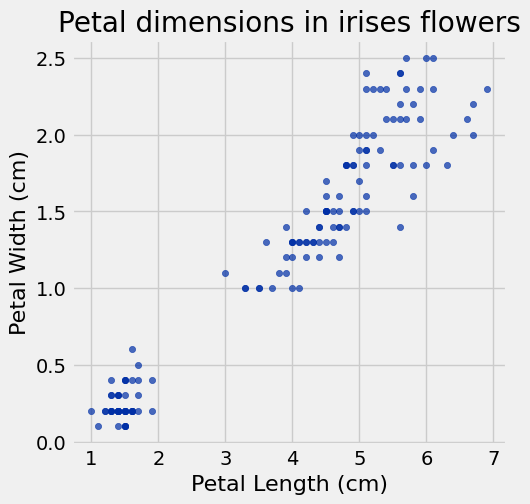

In [ ]:
# Q4. Create a scatter plot with petal_length on the x-axis and petal_width on the y-axis. Add a title to your plot.
# The details of the scatter
iris_data.scatter('PetalLengthCm', 'PetalWidthCm')
plt.title('Petal dimensions in irises flowers')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')

Text(0, 0.5, 'Petal Width (cm)')

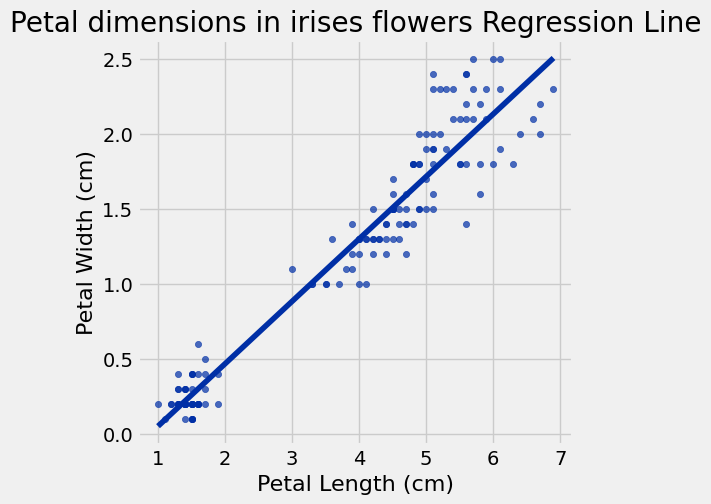

In [ ]:
# Q5. Add a regression line to the scatter plot using fit_line=True. In 1-2 sentences, describe the pattern you observe between the two variables.

iris_data.scatter('PetalLengthCm', 'PetalWidthCm', fit_line=True)
plt.title('Petal dimensions in irises flowers Regression Line')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')

# Q5. Observation: After adding the regression line it directly demonstrates the  positive relationship. Therefore I discovered that there is a positive linear relationship between petal length and petal width. As petal length increases, petal width also increase.

## <font color = blue size  = 5> **Task 3: Linear Regression (3 Marks)**

**Task Description:**
- Use the following helper functions in your notebook to compute the regression line
- Then answer the questions

In [ ]:
def standard_units(arr):
    return (arr - np.mean(arr)) / np.std(arr)


In [ ]:
def correlation(t, x, y):
    return np.mean(standard_units(t.column(x)) * standard_units(t.column(y)))


In [ ]:
def slope(t, x, y):
    r = correlation(t, x, y)
    return r * np.std(t.column(y)) / np.std(t.column(x))


In [ ]:
def intercept(t, x, y):
    return np.mean(t.column(y)) - slope(t, x, y) * np.mean(t.column(x))


In [ ]:
# Q6. Using the helper functions above, compute and print the slope and intercept of the regression line that predicts petal_width from petal_length. Write the full regression equation.

# Compute the slope and the intercept
regression_slope = slope(iris_data, 'PetalLengthCm', 'PetalWidthCm')
regression_intercept = intercept(iris_data, 'PetalLengthCm', 'PetalWidthCm')

print(f"The Slope: {regression_slope:.4f}")
print(f"The Intercept: {regression_intercept:.4f}")

# Regression Equation
# The regression equation is: Petal Width = {regression_slope:.4f} * Petal Length + {regression_intercept:.4f}

The Slope: 0.4164
The Intercept: -0.3665


In [ ]:
# Q7. Use your regression equation to predict the petal width of a flower with petal_length = 4.5 cm. Show your calculation.

# Assigning petal length to be 4.5
petal_length_prediction = 4.5

# Using the previously calculated slope and intercept from Q6
# Slope = 0.4164 and Intercept = -0.3665

predicted_petal_width = regression_slope * petal_length_prediction + regression_intercept

print(f"The predicted petal width is: {predicted_petal_width:.4f} cm")

The predicted petal width is: 1.5074 cm


In [ ]:
# Q8. Compute the correlation coefficient r between petal_length and petal_width. Is the relationship strong or weak? Positive or negative? Explain in 2-3 sentences.

r_cc = correlation(iris_data, 'PetalLengthCm', 'PetalWidthCm')

print(f"Correlation Coefficient (r): {r_cc:.4f}")

# Q8. The correlation coefficient (r) is 0.96 which is extremely close to 1, indicating a very strong positive linear relationship between petal length and petal width. Therefore, as petal length increases, the petal width also increase significantly.

Correlation Coefficient (r): 0.9628


## <font color = blue size  = 5> **Task 4: Residual Analysis (4 Marks)**


- Use the regression line you calculated in the following questions.

In [ ]:
# Q9. Compute the predicted petal_width for every flower using your regression equation. Add both the predicted values and the residuals (actual - predicted) as new columns to the table. Display the first 8 rows.

# Calculate predicted petal width
predicted_petal_widths = iris_data.apply(lambda l: regression_slope * l + regression_intercept, 'PetalLengthCm')

# Calculate residuals
residuals = iris_data.column('PetalWidthCm') - predicted_petal_widths

# Add predicted values and residuals as new columns on the table
iris_data = iris_data.with_columns(
    'PredictedPetalWidth', predicted_petal_widths,
    'Residuals', residuals
)

# Display the first 8 rows of the updated table
iris_data.show(8)

Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,PredictedPetalWidth,Residuals
1,5.1,3.5,1.4,0.2,Iris-setosa,0.216473,-0.0164727
2,4.9,3,1.4,0.2,Iris-setosa,0.216473,-0.0164727
3,4.7,3.2,1.3,0.2,Iris-setosa,0.174831,0.0251692
4,4.6,3.1,1.5,0.2,Iris-setosa,0.258115,-0.0581147
5,5,3.6,1.4,0.2,Iris-setosa,0.216473,-0.0164727
6,5.4,3.9,1.7,0.4,Iris-setosa,0.341398,0.0586015
7,4.6,3.4,1.4,0.3,Iris-setosa,0.216473,0.0835273
8,5,3.4,1.5,0.2,Iris-setosa,0.258115,-0.0581147


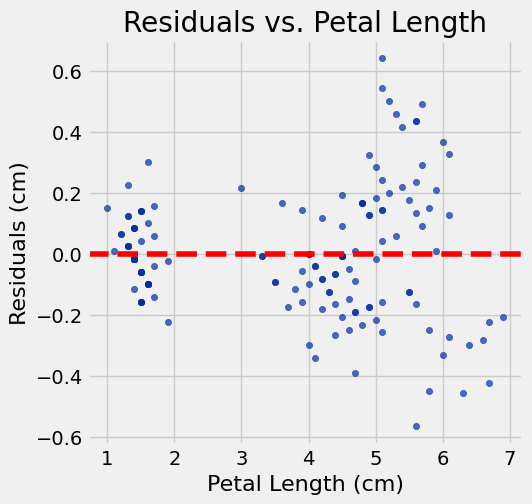

In [ ]:
# Q10. Create a scatter plot of the residuals (y-axis) vs petal_length (x-axis). Add a horizontal red dashed line at y = 0. In 2-3 sentences, interpret what this plot tells you about how well the linear model fits the data.
iris_data.scatter('PetalLengthCm', 'Residuals')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Petal Length')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Residuals (cm)')
plt.show()

# Q10. The points are scattered randomly around the line at y = 0. This means that the linear model fits the data very well. Also, as there is no clear pattern, so the errors are unbiased.

# Submission Guidelines

- Make sure all cells have been run and outputs are visible before submitting.
- Name your file: FirstName_LastName_MA.ipynb
- Add a "Open in Colab" button at the top of your notebook using the following Markdown code:
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/your-repo-path/notebook.ipynb)

- Upload your completed Jupyter Notebook to a GitHub repository.
- Submit the link to your GitHub repository in the Blackboard along with the Jupyter solution file.
- <font color = red size = 6> ATTENTION!!! </font> This is an individual assessment. Students should not work on groups and the submission should be individual.  

# Grading Rubric
based on the following criteria:

- Correctness : The solution produces the expected output using the Table abstraction .
- Clarity : Code is well-organized, readable, and includes comments explaining key steps.
- Creativity : Visualizations and analyses are presented in an engaging and insightful manner.

# Hints for Success
- Use the Table abstraction methods like .select(), .where(), .group(), .apply(), and .sample() for data manipulation.
- Refer to the slides for the regression.
- Test your code frequently to ensure it runs without errors.